In [1]:
import pathlib

import pandas as pd
import numpy as np
import torch

from sklearn.metrics import roc_auc_score, average_precision_score
from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib import pyplot as plt
from torch_geometric.nn import MessagePassing
from captum.attr import IntegratedGradients, Saliency
from rdkit.Chem import rdMolAlign
from rdkit.Chem import AllChem

from mpnn import visualize_all_activations, AllNonZeroReadout
from mpnn.molecule_o_variants import SmoothingMoleculeODetector
from ground_truth.highlight_smarts import highlight_atoms_in_mol, visualize_smarts_match
from krfp_models import krfp_models, name_to_post_smarts, name_to_pre_smarts
from mpnn import one_hot_encode, smiles_to_torch, mol_to_torch, MoleculeGDetector
from datavis import visualize_atom_importance, visualize_atom_importance_from_mol
from mpnn.mpnn_arch import AllNonZeroMaxReadout, AllNonZeroSumReadout

from xai_methods import IGAttributionMethod, SaliencyAttributionMethod
from xai_methods.captum_attributions import ShapleyValueSamplingAttributionMethod
from notebook_utils import get_ig_gradient_paths

In [5]:
def show_attribution(smiles):
    model = SmoothingMoleculeODetector()
    mol = Chem.MolFromSmiles(smiles)

    x, edge_index, edge_features = mol_to_torch(mol, add_hydrogen_ohe=True)

    ig_explainer = IGAttributionMethod(
        model=model,
        model_smarts="",
        positive_smiles=[],  # Not used in this case, but required by the interface
        negative_smiles=[],
    )

    print("Model predicted", model(x, edge_features, edge_index).item())

    atom_importance, _ = ig_explainer.explain(x, edge_features, edge_index)
    atom_importance = torch.sum(torch.abs(atom_importance), dim=1).cpu().numpy().tolist()
    img = visualize_atom_importance_from_mol(
        mol,
        atom_importance,
        length=1000,
        precision=2
    )

    return img

In [6]:
pattern_12_smiles_df = pd.read_csv(
    "artifacts/explainability_method_tester/R2/MoleculeODetector/positive_explainability_results.csv")

smiles = pattern_12_smiles_df["SMILES"].tolist()

Model predicted 1.0


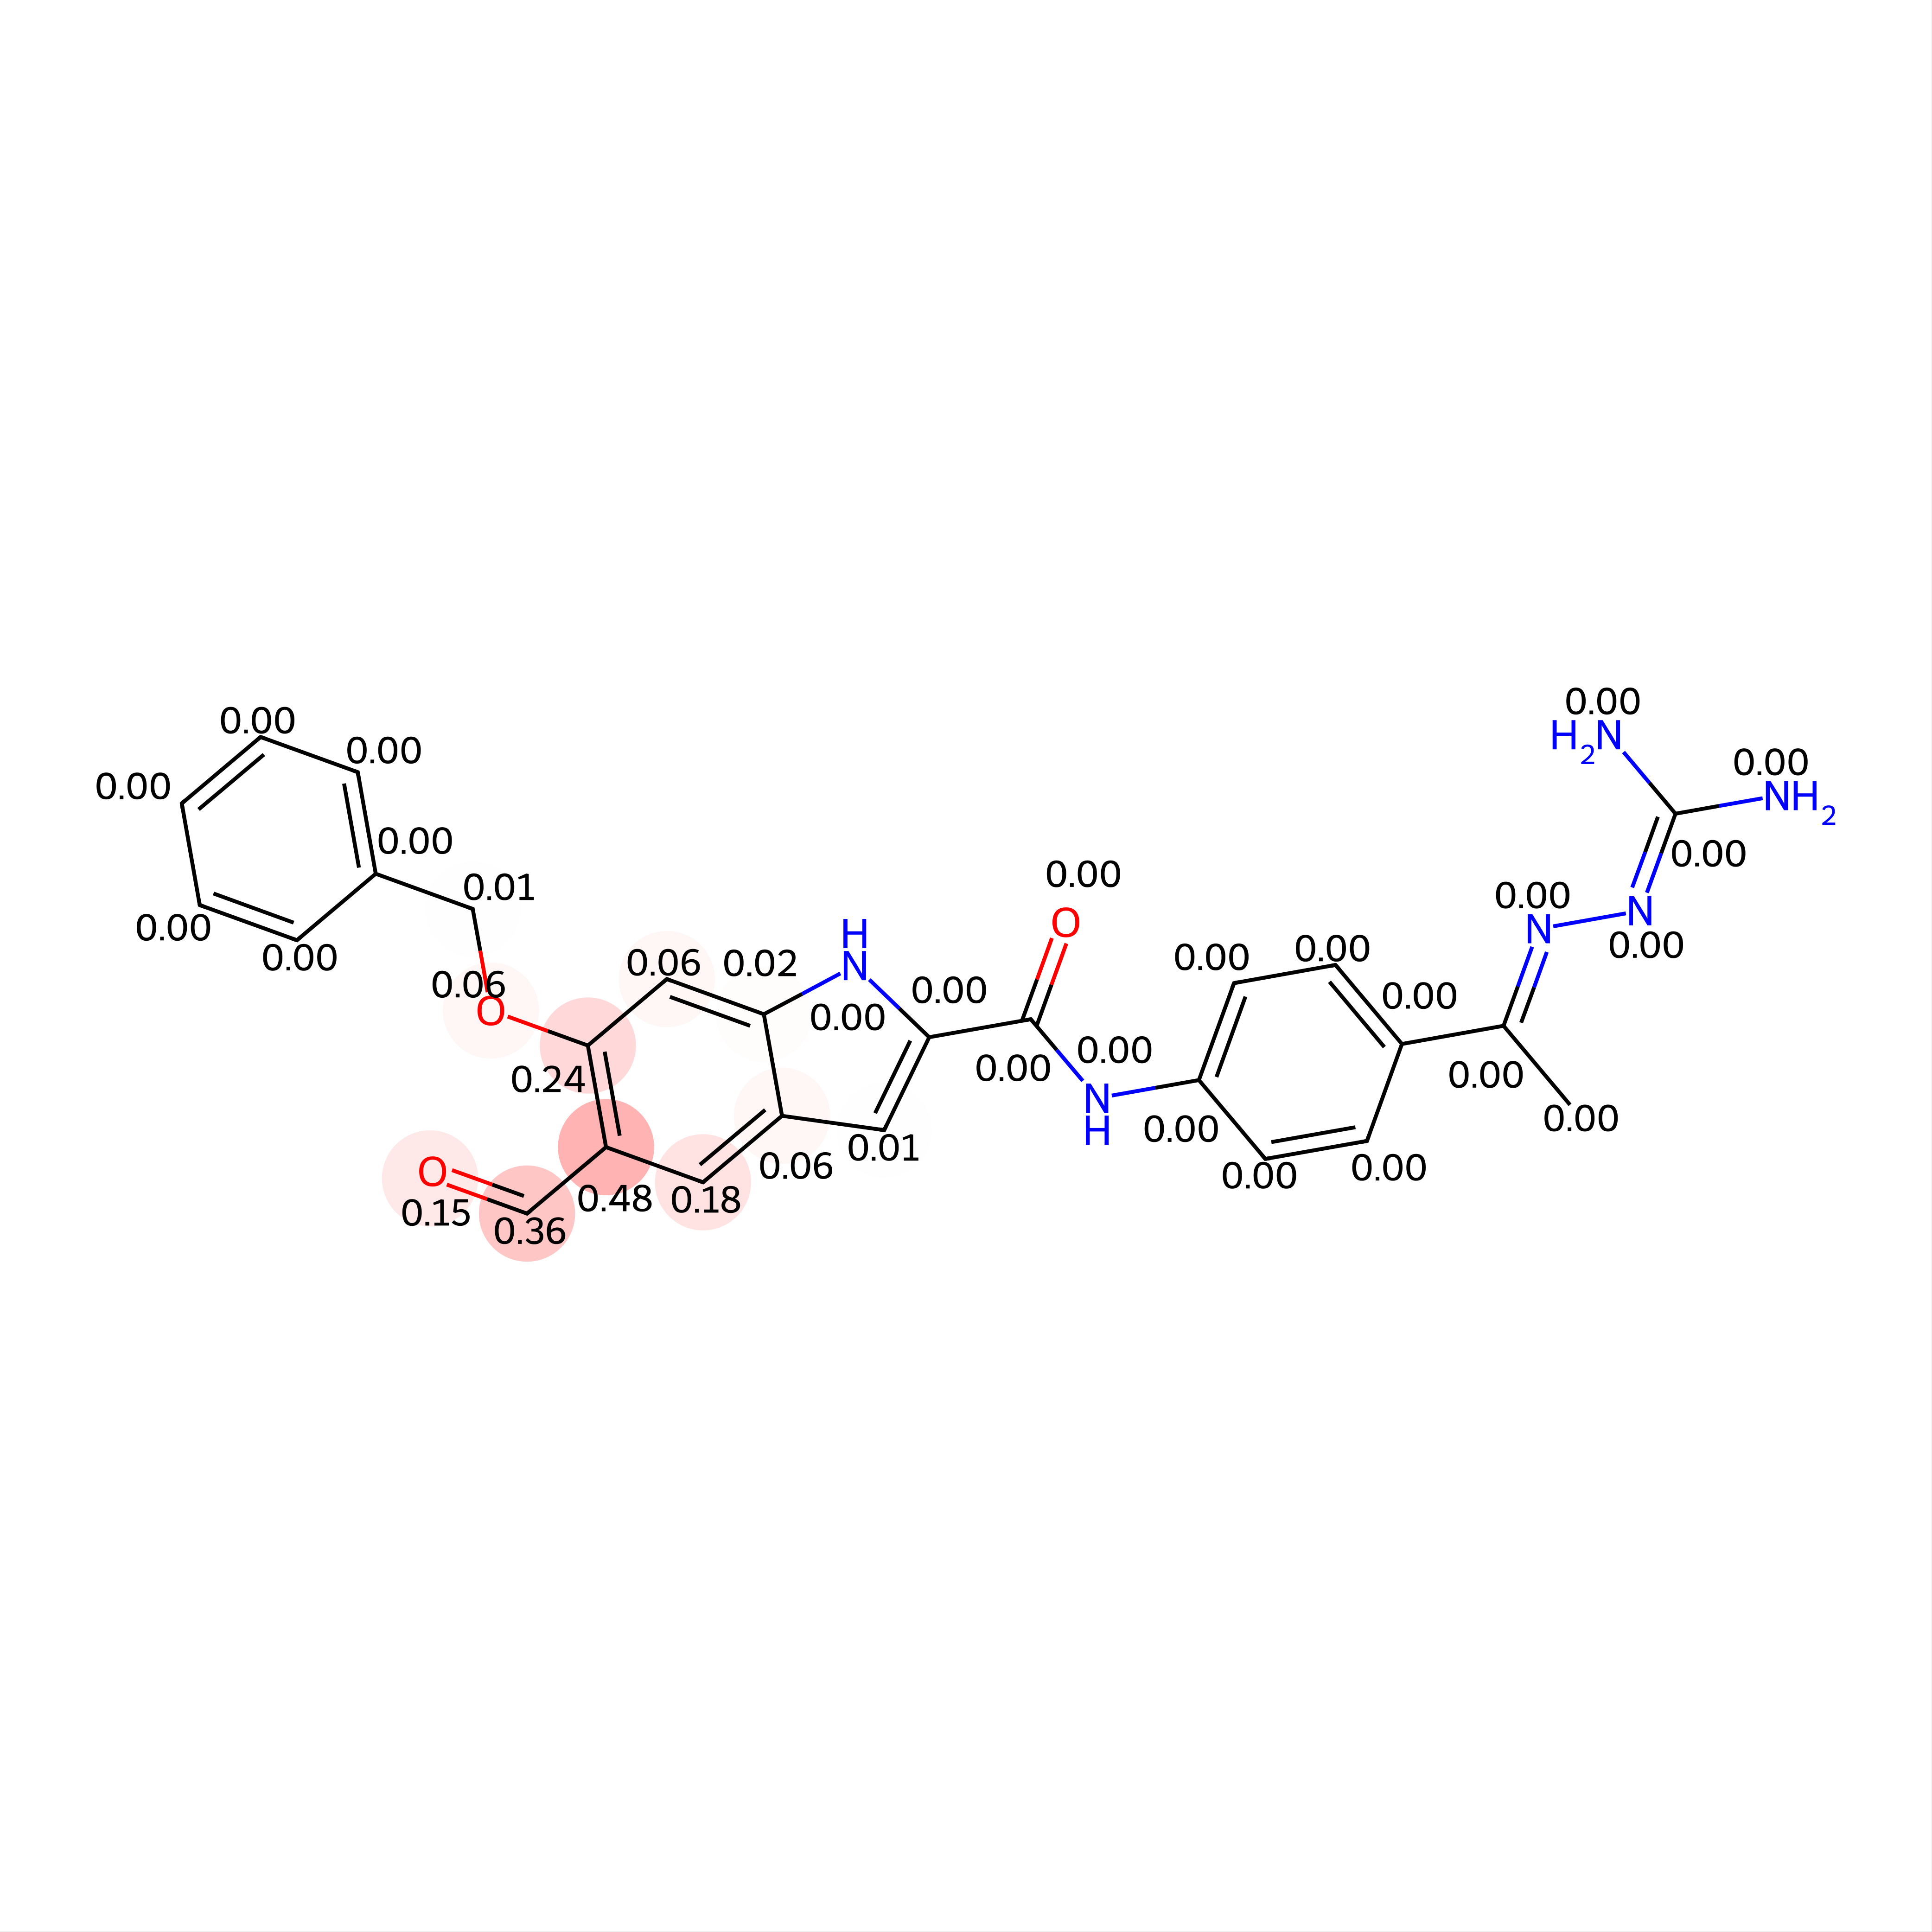

In [7]:
show_attribution(smiles[0])